In [6]:
import pandas as pd

co2 = pd.read_csv(
    'https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',
    header = 0,                   
    names = ['idx', 'co2'],                   
    skipfooter = 2)
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)
co2.index.name = None
co2

/tmp/ipykernel_293530/2416930143.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  co2 = pd.read_csv(


,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17
...,...
1980-08-01,337.19
1980-09-01,335.49
1980-10-01,336.63
1980-11-01,337.74


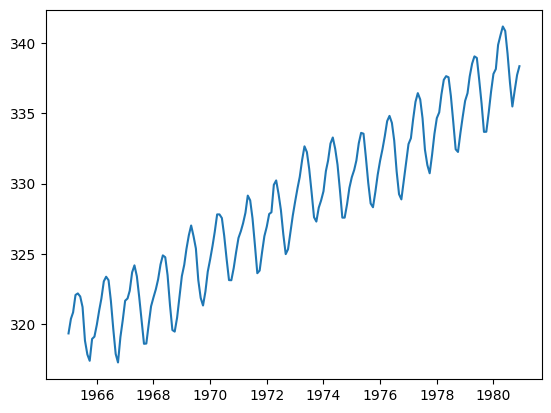

In [ ]:
from matplotlib import pyplot as plt

plt.plot(co2['co2'])

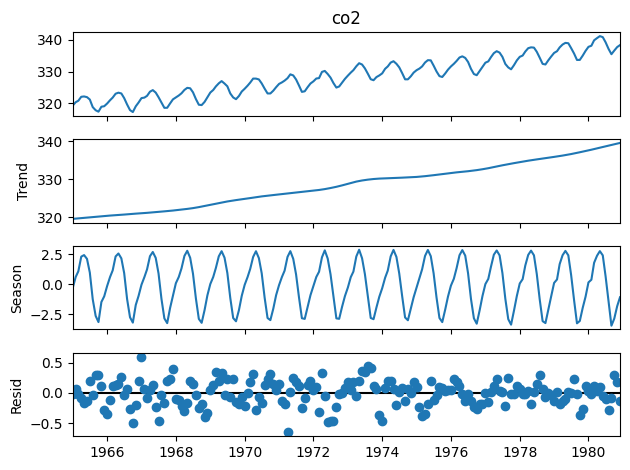

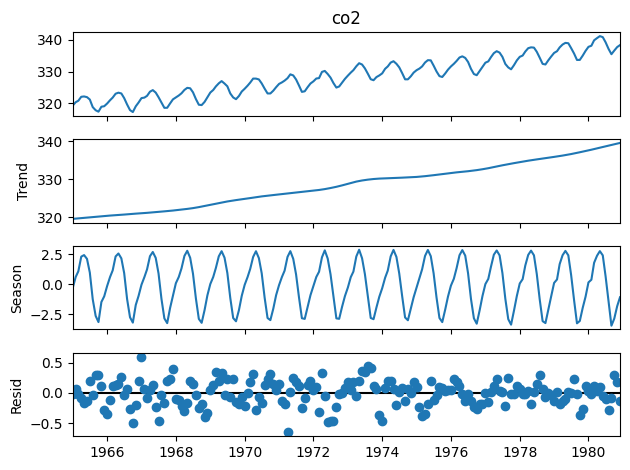

In [ ]:
from statsmodels.tsa.seasonal import STL

# среди данных точно есть тренд и сезонность
# данные не стационарны
STL(co2['co2'],period=12).fit().plot()

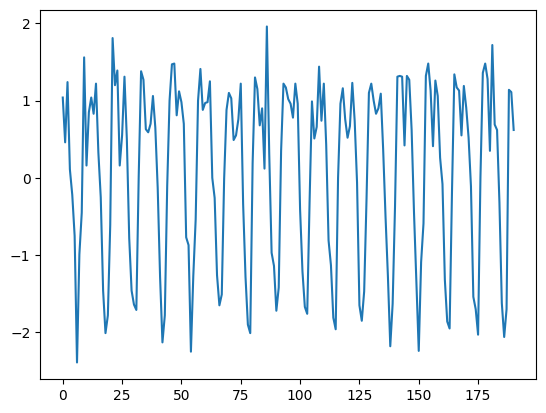

In [12]:
import numpy as np
# приблизим ряд к стационарному
data = np.array(co2['co2'])
data_diff = np.diff(data)
plt.plot(data_diff)

<Figure size 1500x500 with 0 Axes>

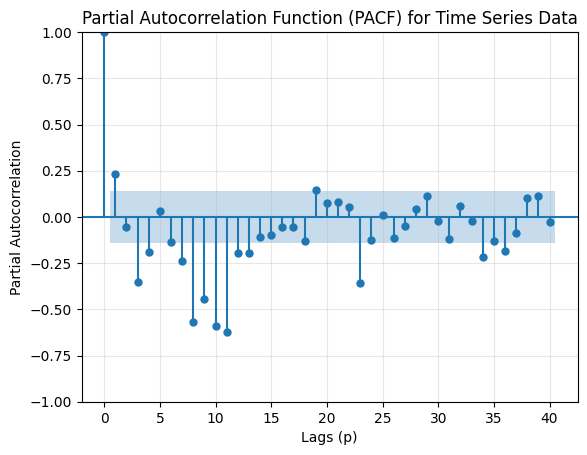

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_pacf

def plot_ar_order_determination(data, lags=40, series_name="Time Series Data"):
    """
    Plots the Partial Autocorrelation Function (PACF) to help determine the 
    order (p) for an Autoregressive (AR) model.
    
    Args:
        data (np.ndarray or pd.Series): The time series data. 
                                        *Must be stationary (no trend/seasonality).*
        lags (int): The number of lags to plot.
        series_name (str): A title for the plot.
    """
    
    # CRITICAL: AR models assume stationarity. We must remove trend/seasonality first.
    # We use differencing as a quick method as discussed earlier.
    if isinstance(data, np.ndarray):
        data = pd.Series(data)
        
    # We apply a single difference to remove a linear trend
    stationary_data = data.diff().dropna()

    plt.figure(figsize=(15, 5))
    # 'ols' (Ordinary Least Squares) is a common method for PACF calculation
    plot_pacf(stationary_data, lags=lags, method='ols', title=f'Partial Autocorrelation Function (PACF) for {series_name}')
    
    plt.xlabel('Lags (p)')
    plt.ylabel('Partial Autocorrelation')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_ar_order_determination(
    data_diff,
    lags=40
)
# у нас тут примерно 24 лага 

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import itertools
import warnings

warnings.filterwarnings("ignore")

def select_best_sarimax(data, test_size=10, seasonal_period=12):
    # Убедимся, что данные - это Series с числовым индексом или DatetimeIndex
    if isinstance(data, np.ndarray):
        data = pd.Series(data)
    
    train = data.iloc[:-test_size]
    test = data.iloc[-test_size:]
    
    # Сократим сетку для стабильности: p, d, q в пределах 0-1
    p = d = q = [0, 1] 
    pdq = list(itertools.product(p, d, q))
    # Сезонные (P, D, Q)
    seasonal_pdq = [(x[0], x[1], x[2], seasonal_period) for x in itertools.product(p, d, q)]
    
    best_rmse = float("inf")
    best_cfg = None

    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                # Настройка SARIMAX
                model = sm.tsa.statespace.SARIMAX(
                    train,
                    order=param,
                    seasonal_order=param_seasonal,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False)
                
                # Прогноз
                forecast = results.get_forecast(steps=test_size).predicted_mean
                rmse = np.sqrt(mean_squared_error(test, forecast))
                
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_cfg = (param, param_seasonal)
            except:
                continue

    # Проверка: нашли ли мы хоть одну модель?
    if best_cfg is None:
        return "Не удалось подобрать модель. Попробуйте уменьшить seasonal_period или проверить данные на наличие NaN."
    
    print(f'Лучшая модель: SARIMAX{best_cfg[0]}x{best_cfg[1]}')
    print(f'RMSE на тесте: {best_rmse:.4f}')
    return best_cfg

# Пример вызова (замените на ваш сигнал):
best_params = select_best_sarimax(data, test_size=10)


Лучшая модель: SARIMAX(1, 0, 1)x(1, 0, 0, 12)
RMSE на тесте: 0.5237


In [24]:
# !pip install pmdarima

Running Sklearn GridSearch...
Running AutoARIMA...


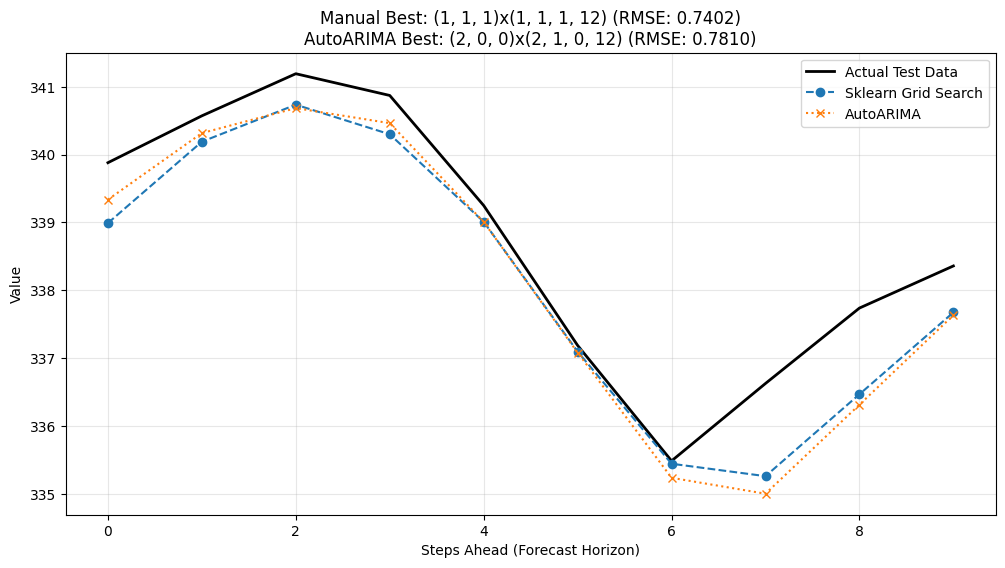

(SARIMAXWrapper(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)),
 ARIMA(order=(2, 0, 0), scoring_args={}, seasonal_order=(2, 1, 0, 12),
       suppress_warnings=True))

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings

warnings.filterwarnings("ignore")

# 1. Wrapper for Statsmodels SARIMAX to make it sklearn-compatible
class SARIMAXWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, order=(1, 0, 1), seasonal_order=(0, 0, 0, 0)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.model_res_ = None

    def fit(self, X, y=None):
        # Statsmodels uses endog (y), X is usually ignored unless exogenous
        self.model_ = SARIMAX(
            X, 
            order=self.order, 
            seasonal_order=self.seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        self.model_res_ = self.model_.fit(disp=False)
        return self

    def predict(self, X):
        # X here represents the steps/index for prediction
        forecast = self.model_res_.get_forecast(steps=len(X))
        return forecast.predicted_mean

def compare_with_sklearn_grid(data, test_size=10, s=12):
    # Ensure data is handled correctly whether it's Series or Array
    if isinstance(data, pd.Series) or isinstance(data, pd.DataFrame):
        train = data.iloc[:-test_size]
        test = data.iloc[-test_size:]
    else:
        train = data[:-test_size]
        test = data[-test_size:]
    
    # Reduced Search Space
    param_grid = {
        'order': [(1,1,1), (2,1,0), (0,1,1)],
        'seasonal_order': [(1,1,1,s), (0,1,1,s), (0,0,0,0)]
    }
    
    # GridSearch
    tscv = TimeSeriesSplit(n_splits=2)
    grid = GridSearchCV(
        SARIMAXWrapper(), 
        param_grid, 
        cv=tscv, 
        scoring='neg_root_mean_squared_error'
    )
    
    print("Running Sklearn GridSearch...")
    grid.fit(train)
    best_manual = grid.best_estimator_
    
    # Get Predictions
    manual_fcast = best_manual.predict(test)
    
    print("Running AutoARIMA...")
    auto_mod = auto_arima(train, seasonal=True, m=s, suppress_warnings=True)
    auto_fcast = auto_mod.predict(n_periods=test_size)
    
    # Calculate RMSE
    # Ensure everything is a numpy array for calculation
    test_arr = np.asarray(test).flatten()
    manual_fcast_arr = np.asarray(manual_fcast).flatten()
    auto_fcast_arr = np.asarray(auto_fcast).flatten()
    
    m_rmse = np.sqrt(mean_squared_error(test_arr, manual_fcast_arr))
    a_rmse = np.sqrt(mean_squared_error(test_arr, auto_fcast_arr))
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Use generic range for X axis to avoid index mismatch errors
    x_axis = np.arange(len(test_arr))
    
    plt.plot(x_axis, test_arr, label='Actual Test Data', color='black', lw=2)
    plt.plot(x_axis, manual_fcast_arr, label='Sklearn Grid Search', linestyle='--', marker='o')
    plt.plot(x_axis, auto_fcast_arr, label='AutoARIMA', linestyle=':', marker='x')
    
    plt.title(f"Manual Best: {best_manual.order}x{best_manual.seasonal_order} (RMSE: {m_rmse:.4f})\n"
              f"AutoARIMA Best: {auto_mod.order}x{auto_mod.seasonal_order} (RMSE: {a_rmse:.4f})")
    plt.xlabel("Steps Ahead (Forecast Horizon)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return best_manual, auto_mod


compare_with_sklearn_grid(data,test_size=10)